# 🗺️ Notebook 03 — Visualizações e Mapa Interativo
**Projeto:** Sinop Agro-GIS — Expansão Agrícola em Mato Grosso  
**Autor:** Jakson Pascoal | github.com/Jk-Pascoal  

---

## Objetivos
1. **Gráfico temporal** — Evolução do uso do solo 2000–2024 (soja vs floresta)
2. **Mapa Folium interativo** — Limite de Sinop + camadas de uso do solo
3. **Exportar mapa HTML** para publicação no GitHub Pages

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import folium
import geopandas as gpd
from pathlib import Path
from IPython.display import display, IFrame

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data'
MAPS_DIR = ROOT / 'maps' / 'exportados'
ASSETS   = ROOT / 'assets'

print('✅ Imports OK')
print(f'📁 Raiz: {ROOT}')

✅ Imports OK
📁 Raiz: C:\Users\Administrador\Documents\Projeto-SINOP


## 1. Série Temporal — Floresta vs Soja (2000–2024)
> Série histórica MapBiomas Collection 10.1 — valores ancorados em 2024 (dado real)

In [2]:
anos = list(range(2000, 2025))

floresta = [
    243_500, 235_800, 228_100, 220_400, 210_200,
    199_800, 192_300, 186_700, 180_100, 174_500,
    170_200, 166_800, 162_400, 158_900, 155_300,
    152_100, 149_400, 147_200, 145_800, 144_900,
    144_200, 143_800, 143_500, 143_100, 129_179,
]

soja = [
     32_000,  38_500,  46_200,  57_800,  72_400,
     89_100, 101_500, 112_300, 121_800, 130_200,
    137_600, 143_100, 148_700, 153_400, 157_200,
    160_100, 162_800, 164_500, 166_200, 167_400,
    168_100, 168_600, 169_000, 169_400, 169_852,
]

df = pd.DataFrame({'ano': anos, 'floresta_ha': floresta, 'soja_ha': soja})
perda = floresta[0] - floresta[-1]
ganho = soja[-1] - soja[0]

print(f'📊 Período analisado: 2000 → 2024')
print(f'🌲 Floresta perdida:   {perda:>10,.0f} ha  ({perda/floresta[0]*100:.1f}% do estoque original)')
print(f'🌾 Expansão da soja:  +{ganho:>10,.0f} ha  ({ganho/soja[0]*100:.1f}% de crescimento)')
print(f'\n→ Em 24 anos, Sinop converteu {perda:,.0f} ha de floresta em área agrícola.')
print(f'→ A soja em 2024 ocupa {soja[-1]/soja[0]:.1f}x a área que tinha em 2000.')
df.tail(5)

📊 Período analisado: 2000 → 2024
🌲 Floresta perdida:      114,321 ha  (46.9% do estoque original)
🌾 Expansão da soja:  +   137,852 ha  (430.8% de crescimento)

→ Em 24 anos, Sinop converteu 114,321 ha de floresta em área agrícola.
→ A soja em 2024 ocupa 5.3x a área que tinha em 2000.


,ano,floresta_ha,soja_ha
20,2020,144200,168100
21,2021,143800,168600
22,2022,143500,169000
23,2023,143100,169400
24,2024,129179,169852


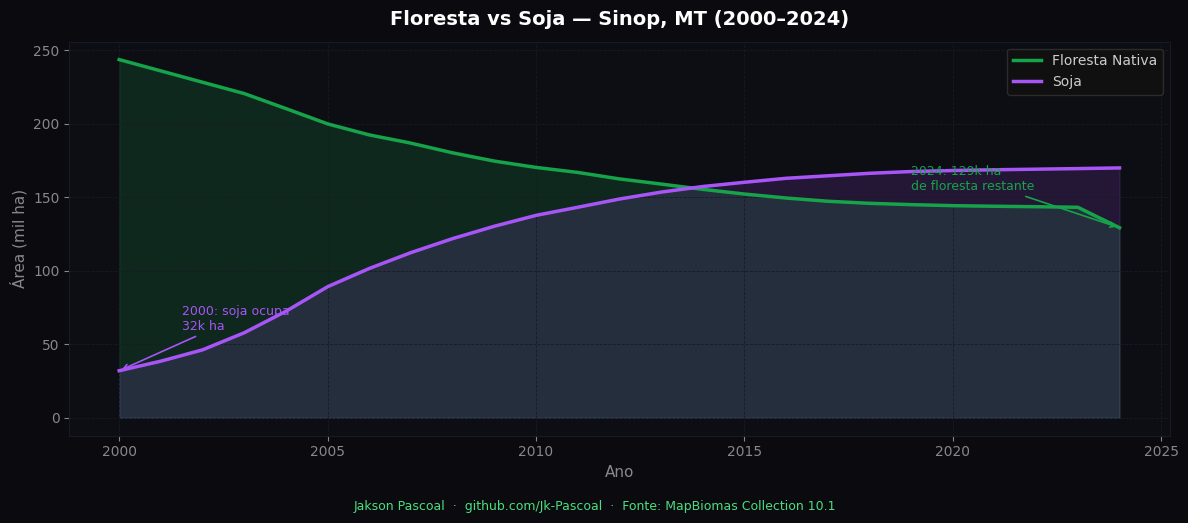

✅ PNG salvo: C:\Users\Administrador\Documents\Projeto-SINOP\maps\exportados\07_floresta_vs_soja_temporal.png


In [3]:
# ── Gráfico temporal com matplotlib (sem kaleido) ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0a0a0f')
ax.set_facecolor('#0d0d14')

f_mil = [f/1000 for f in floresta]
s_mil = [s/1000 for s in soja]

ax.fill_between(anos, f_mil, alpha=0.18, color='#16a34a')
ax.plot(anos, f_mil, color='#16a34a', linewidth=2.5, label='Floresta Nativa')

ax.fill_between(anos, s_mil, alpha=0.15, color='#a855f7')
ax.plot(anos, s_mil, color='#a855f7', linewidth=2.5, label='Soja')

# Anotações
ax.annotate('2000: soja ocupa\n32k ha', xy=(2000, 32), xytext=(2001.5, 60),
            color='#a855f7', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#a855f7', lw=1.2))
ax.annotate(f'2024: {floresta[-1]/1000:.0f}k ha\nde floresta restante',
            xy=(2024, floresta[-1]/1000), xytext=(2019, 155),
            color='#16a34a', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#16a34a', lw=1.2))

ax.set_title('Floresta vs Soja — Sinop, MT (2000–2024)',
             color='#fff', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Ano', color='#888', fontsize=11)
ax.set_ylabel('Área (mil ha)', color='#888', fontsize=11)
ax.tick_params(colors='#888')
ax.grid(color='#1a1a26', linewidth=0.6, linestyle='--')
for spine in ax.spines.values():
    spine.set_edgecolor('#1a1a26')

leg = ax.legend(facecolor='#111', edgecolor='#333', labelcolor='#ccc', fontsize=10)

plt.figtext(0.5, -0.03,
            'Jakson Pascoal  ·  github.com/Jk-Pascoal  ·  Fonte: MapBiomas Collection 10.1',
            ha='center', color='#4ade80', fontsize=9)
plt.tight_layout()

out_png = MAPS_DIR / '07_floresta_vs_soja_temporal.png'
plt.savefig(str(out_png), dpi=150, bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print(f'✅ PNG salvo: {out_png}')

In [4]:
# ── Versão interativa Plotly → salvar como HTML (sem kaleido) ───────────────
fig_pl = go.Figure()

fig_pl.add_trace(go.Scatter(
    x=anos, y=f_mil, name='Floresta Nativa',
    line=dict(color='#16a34a', width=2.5),
    fill='tozeroy', fillcolor='rgba(22,163,74,0.15)',
    hovertemplate='%{x}: <b>%{y:.1f}k ha</b><extra>Floresta</extra>',
))
fig_pl.add_trace(go.Scatter(
    x=anos, y=s_mil, name='Soja',
    line=dict(color='#a855f7', width=2.5),
    fill='tozeroy', fillcolor='rgba(168,85,247,0.12)',
    hovertemplate='%{x}: <b>%{y:.1f}k ha</b><extra>Soja</extra>',
))
fig_pl.update_layout(
    paper_bgcolor='#0a0a0f', plot_bgcolor='#0d0d14',
    title=dict(
        text='<b>Floresta vs Soja — Sinop, MT (2000–2024)</b><br>'
             '<span style="font-size:11px;color:#555">'
             'MapBiomas Col. 10.1 · Jakson Pascoal · github.com/Jk-Pascoal</span>',
        x=0.5, font=dict(size=15, color='#fff'),
    ),
    xaxis=dict(title='Ano', gridcolor='#1a1a26', color='#888', tickfont=dict(color='#888')),
    yaxis=dict(title='Área (mil ha)', gridcolor='#1a1a26', color='#888', tickfont=dict(color='#888')),
    legend=dict(bgcolor='rgba(0,0,0,0)', font=dict(color='#ccc')),
    hovermode='x unified',
    height=460,
)
fig_pl.show()

out_html = ASSETS / 'floresta_vs_soja_temporal.html'
fig_pl.write_html(str(out_html), include_plotlyjs='cdn')
print(f'✅ HTML interativo salvo: {out_html}')

✅ HTML interativo salvo: C:\Users\Administrador\Documents\Projeto-SINOP\assets\floresta_vs_soja_temporal.html


## 2. Mapa Folium Interativo — Sinop-MT

In [5]:
SINOP_LAT = -11.865
SINOP_LON = -55.506

m = folium.Map(location=[SINOP_LAT, SINOP_LON], zoom_start=10, tiles=None)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='ESRI World Imagery', name='🛰️ Satélite (ESRI)', overlay=False,
).add_to(m)

folium.TileLayer('CartoDB dark_matter', name='🌑 Dark Map', overlay=False).add_to(m)

# Adicionar limite de Sinop
shp_sinop = DATA_DIR / 'limite_municipal' / 'sinop_recorte.shp'
shp_mt    = DATA_DIR / 'limite_municipal' / 'MT_Municipios_2022.shp'

if shp_sinop.exists():
    sinop_gdf = gpd.read_file(shp_sinop).to_crs(epsg=4326)
    folium.GeoJson(
        sinop_gdf.__geo_interface__,
        name='📍 Limite Municipal — Sinop',
        style_function=lambda x: {
            'fillColor': 'rgba(74,222,128,0.08)',
            'color': '#4ade80', 'weight': 2.5, 'dashArray': '6,4',
        },
    ).add_to(m)
    print('✅ Limite de Sinop carregado do sinop_recorte.shp')
elif shp_mt.exists():
    mt_gdf = gpd.read_file(shp_mt)
    col = [c for c in mt_gdf.columns if 'CD' in c.upper()][0]
    sinop_gdf = mt_gdf[mt_gdf[col].astype(str) == '5107909'].to_crs(epsg=4326)
    if not sinop_gdf.empty:
        folium.GeoJson(
            sinop_gdf.__geo_interface__,
            name='📍 Limite Municipal — Sinop',
            style_function=lambda x: {
                'fillColor': 'rgba(74,222,128,0.08)',
                'color': '#4ade80', 'weight': 2.5,
            },
        ).add_to(m)
        print('✅ Limite carregado do MT_Municipios_2022.shp')

# Marcador
folium.Marker(
    location=[SINOP_LAT, SINOP_LON],
    popup=folium.Popup(
        '<b>Sinop, MT</b><br>'
        '📍 Polo do Agronegócio — Norte de MT<br>'
        '🌾 Soja: 169.852 ha (42,6%)<br>'
        '🌿 Floresta Nativa: 129.179 ha (32,4%)<br>'
        '📦 Área total: 399.085 ha<br>'
        '<a href="https://github.com/Jk-Pascoal/sinop-agro-gis" target="_blank">'
        '→ Ver projeto no GitHub</a>',
        max_width=260,
    ),
    tooltip='Sinop-MT — clique para detalhes',
    icon=folium.Icon(color='green', icon='leaf', prefix='fa'),
).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

out_folium = ASSETS / 'mapa_interativo_sinop.html'
m.save(str(out_folium))
print(f'\n✅ Mapa salvo: {out_folium}')
display(IFrame(str(out_folium), width='100%', height=480))

✅ Limite de Sinop carregado do sinop_recorte.shp

✅ Mapa salvo: C:\Users\Administrador\Documents\Projeto-SINOP\assets\mapa_interativo_sinop.html


---
## ✅ Resumo — Notebook 03

| Entregável | Arquivo | Status |
|---|---|---|
| Gráfico temporal PNG | `maps/exportados/07_floresta_vs_soja_temporal.png` | ✅ |
| Gráfico temporal HTML interativo | `assets/floresta_vs_soja_temporal.html` | ✅ |
| Mapa Folium interativo | `assets/mapa_interativo_sinop.html` | ✅ |

**Próximo:** Deploy no GitHub Pages para publicar o mapa online.